In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [2]:
# Load dataset
df = sns.load_dataset('titanic')

# Select useful columns only
df = df[['survived','pclass','sex','age','sibsp','parch','fare','embarked']]

# Fill missing values
df['age'].fillna(df['age'].median(), inplace=True)
df['fare'].fillna(df['fare'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Convert text columns to numbers
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])        # male=1, female=0
df['embarked'] = le.fit_transform(df['embarked'])  # C=0, Q=1, S=2

print("✅ Dataset ready!")
print(f"Shape: {df.shape}")
df.head()

✅ Dataset ready!
Shape: (891, 8)


/tmp/ipykernel_31299/4041836141.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_31299/4041836141.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [3]:
# X = input features, y = target (what we predict)
X = df.drop('survived', axis=1)
y = df['survived']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Data split done!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

✅ Data split done!
Training samples : 712
Testing  samples : 179


In [4]:
# 1. Logistic Regression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# 2. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# 3. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("✅ All 3 models trained!")
print(f"Logistic Regression Accuracy : {accuracy_score(y_test, lr_pred)*100:.2f}%")
print(f"Decision Tree Accuracy       : {accuracy_score(y_test, dt_pred)*100:.2f}%")
print(f"Random Forest Accuracy       : {accuracy_score(y_test, rf_pred)*100:.2f}%")

✅ All 3 models trained!
Logistic Regression Accuracy : 81.01%
Decision Tree Accuracy       : 78.21%
Random Forest Accuracy       : 82.12%


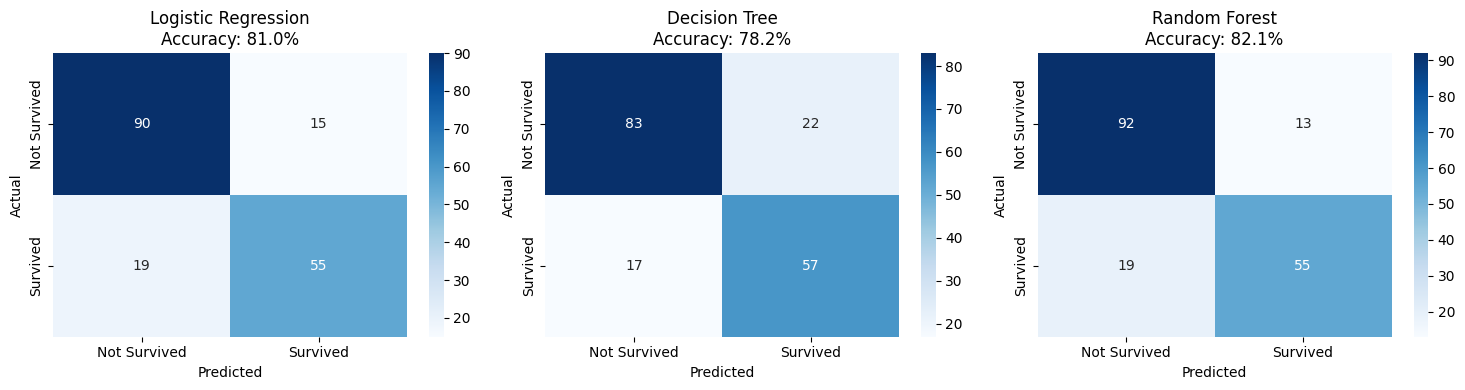

✅ Confusion matrices saved!


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ("Logistic Regression", lr_pred),
    ("Decision Tree",       dt_pred),
    ("Random Forest",       rf_pred)
]

for ax, (name, pred) in zip(axes, models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Survived','Survived'],
                yticklabels=['Not Survived','Survived'])
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, pred)*100:.1f}%')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved!")

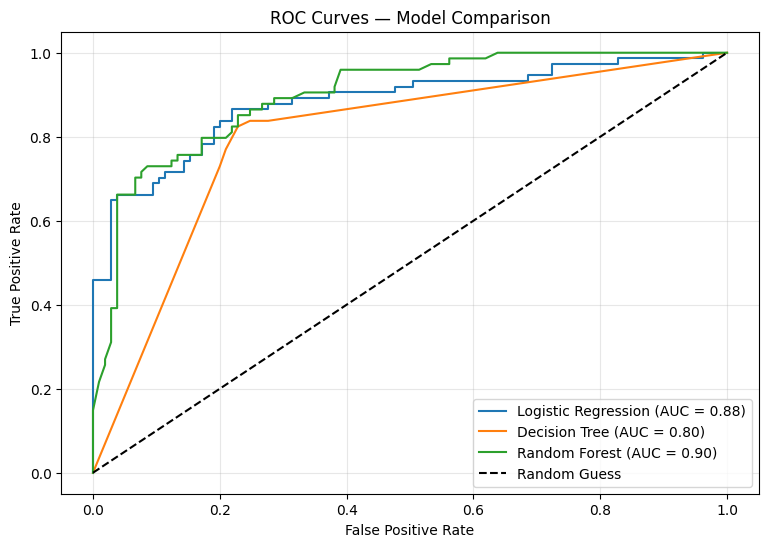

✅ ROC curves saved!


In [6]:
plt.figure(figsize=(9, 6))

for name, model in [("Logistic Regression", lr),
                     ("Decision Tree", dt),
                     ("Random Forest", rf)]:
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC curves saved!")

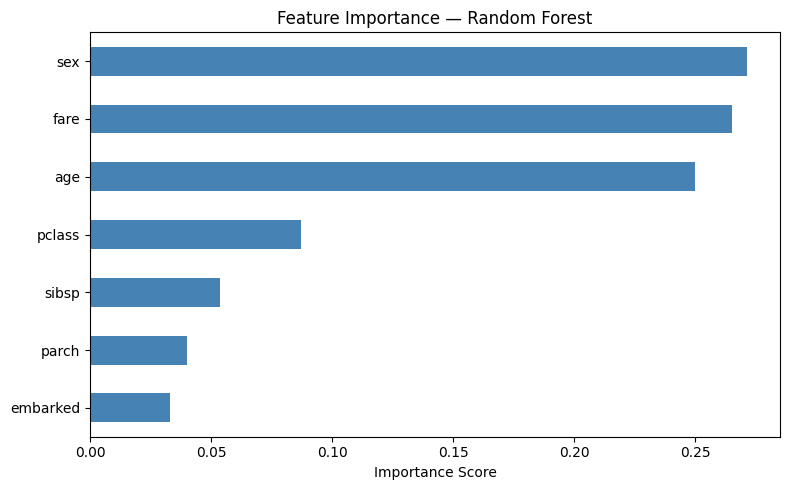

✅ Feature importance chart saved!


In [7]:
plt.figure(figsize=(8, 5))
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance chart saved!")

In [8]:
print("=" * 50)
print("   FINAL MODEL PERFORMANCE REPORT")
print("=" * 50)

for name, pred in [("Logistic Regression", lr_pred),
                    ("Decision Tree",       dt_pred),
                    ("Random Forest",       rf_pred)]:
    print(f"\n📊 {name}")
    print(f"   Accuracy: {accuracy_score(y_test, pred)*100:.2f}%")

print("\n" + "=" * 50)
print("   DETAILED REPORT — Random Forest (Best Model)")
print("=" * 50)
print(classification_report(y_test, rf_pred,
      target_names=['Not Survived','Survived']))

print("\n🎉 Task 2 COMPLETE!")
print("\nFiles saved:")
print("  • confusion_matrices.png")
print("  • roc_curves.png")
print("  • feature_importance.png")

   FINAL MODEL PERFORMANCE REPORT

📊 Logistic Regression
   Accuracy: 81.01%

📊 Decision Tree
   Accuracy: 78.21%

📊 Random Forest
   Accuracy: 82.12%

   DETAILED REPORT — Random Forest (Best Model)
              precision    recall  f1-score   support

Not Survived       0.83      0.88      0.85       105
    Survived       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179


🎉 Task 2 COMPLETE!

Files saved:
  • confusion_matrices.png
  • roc_curves.png
  • feature_importance.png
